In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import glob
from spark_session import get_spark_session

print("Importaciones completas.")

Importaciones completas.


In [ ]:
# --- 2. PARÁMETROS DE CONFIGURACIÓN ---

# Ruta LAPTOP (Host) - Para que el Driver lea los archivos
HOST_DATA_PATH = "./../../data" 
# Ruta DENTRO de los contenedores Docker (como en docker-compose.yml)
CONTAINER_DATA_PATH = "/opt/spark/data"

# Ruta base donde se guardarán los resultados (en el Host, para la limpieza inicial)
OUTPUT_HOST_PATH = os.path.join(HOST_DATA_PATH, "processed")
# Ruta base donde los workers escribirán (en el Contenedor)
OUTPUT_CONTAINER_PATH = os.path.join(CONTAINER_DATA_PATH, "processed")

N_SLICES = 16

IMAGE_LIMIT = 1

In [27]:
# --- 3. INICIALIZAR SESIÓN DE SPARK ---
print("Iniciando SparkSession en modo distribuido...")
spark = get_spark_session("TreeRingSlicing (Distributed)")

sc = spark.sparkContext
print("\n--- SparkSession Iniciada --- ✅")
print(f"Spark Version: {sc.version}")
print(f"Master: {sc.master}")
print(f"UI Web: {sc.uiWebUrl}")

Iniciando SparkSession en modo distribuido...
Attempting to connect to master at: spark://localhost:7077
Will announce driver host IP as: 172.26.0.1
Check: IP 172.26.0.1 resolves locally.

--- Connection Successful! --- ✅
SparkSession object: <pyspark.sql.session.SparkSession object at 0x7fa4781ee320>
SparkContext object: <SparkContext master=spark://localhost:7077 appName=TreeRingSlicing (Distributed)>
Spark version in use: 4.0.1

--- SparkSession Iniciada --- ✅
Spark Version: 4.0.1
Master: spark://localhost:7077
UI Web: http://172.26.0.1:4040


In [28]:
# --- 4. FUNCIONES AUXILIARES ---

def load_pith_locations(metadata_path):
    """
    Carga el CSV de ubicaciones del centro (pith) en un diccionario
    para una búsqueda rápida.
    """
    try:
        csv_path = os.path.join(metadata_path, 'pith_location.csv')
        df = pd.read_csv(csv_path)
        # Convertimos a un diccionario: {'F10b': (cx, cy)}
        # Nota: El CSV tiene (cy, cx), lo invertimos a (cx, cy) para OpenCV
        pith_dict = {row['Image']: (row['cx'], row['cy']) for index, row in df.iterrows()}
        
        print(f"Loaded {len(pith_dict)} pith from CSV.")
        return pith_dict
        
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {csv_path}")
        return {}
    except Exception as e:
        print(f"Error cargando CSV: {e}")
        return {}

def get_image_files(raw_path, limit=None):
    """
    Escanea la carpeta 'raw' y devuelve una lista de nombres de archivo de imagen.
    """
    try:
        all_files = [f for f in os.listdir(raw_path) if f.lower().endswith('.png')]
        all_files.sort()
        
        if limit is not None:
            print(f"Se encontraron {len(all_files)} imágenes. Procesando las primeras {limit}.")
            return all_files[:limit]
        else:
            print(f"Se encontraron y procesarán {len(all_files)} imágenes.")
            return all_files
            
    except FileNotFoundError:
        print(f"Error: No se encontró el directorio 'raw' en {raw_path}")
        return []

In [29]:
# --- 5. WORKER PROCESSING LOGIC ---

def process_image_slice(image_name, base_data_path, output_base_path, n_slices, pith_locations_broadcast):
    """
    Main function that will run in parallel on each worker.
    Takes an image name, loads it, divides it into N slices,
    and saves each slice cropped to its bounding box.
    """
    # --------------------------------------------------
    # 1. Setup paths and data
    # --------------------------------------------------
    try:    
        # Reconstruct paths (workers don't know global variables)
        image_path = os.path.join(base_data_path, 'raw', image_name)
        image_name_no_ext = os.path.splitext(image_name)[0]
        
        # Get pith centers dictionary from broadcast variable
        pith_map = pith_locations_broadcast.value
        
        # Load the image
        img = cv2.imread(image_path)
        if img is None:
            return (image_name, "ERROR: Could not read image")
            
        h, w, _ = img.shape
        
        # --------------------------------------------------
        # 2. Find the center (Pith)
        # --------------------------------------------------
        if image_name_no_ext not in pith_map:
            return (image_name, f"ERROR: Pith center not found for {image_name_no_ext}")
            
        # (cx, cy) - OpenCV format (x, y)
        (cy, cx) = pith_map[image_name_no_ext]
        
        # --------------------------------------------------
        # 3. Create and save each slice (cropped to bounding box)
        # --------------------------------------------------
        
        # Calculate maximum radius to cover entire image from center
        radius = int(np.sqrt(max(cx, w - cx)**2 + max(cy, h - cy)**2)) + 1
        
        # Define output directory for this image
        output_dir = os.path.join(output_base_path, str(n_slices), image_name_no_ext)
        os.makedirs(output_dir, exist_ok=True)
        
        angle_per_slice = 360.0 / n_slices
        
        slices_saved = 0
        total_size_original = 0
        total_size_cropped = 0
        
        for i in range(n_slices):
            # Calculate start and end angles for the slice
            # Subtract 90 degrees because cv2.ellipse starts at 3 o'clock,
            # and we want to start at 12 o'clock
            start_angle = (i * angle_per_slice) - 90
            end_angle = ((i + 1) * angle_per_slice) - 90
            
            # 1. Create blank mask
            mask = np.zeros((h, w), dtype=np.uint8)
            
            # 2. Draw the "pie slice" (ellipse sector) on the mask
            cv2.ellipse(
                mask,
                center=(int(cx), int(cy)),
                axes=(int(radius), int(radius)),
                angle=0,
                startAngle=start_angle,
                endAngle=end_angle,
                color=255,
                thickness=-1
            )
            
            # 3. Apply mask to original image
            result = cv2.bitwise_and(img, img, mask=mask)
            
            # --------------------------------------------------
            # 4. OPTIMIZATION: Crop to bounding box
            # --------------------------------------------------
            # Find contours in the mask to get bounding box
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                # Get bounding rectangle of the largest contour
                x, y, bbox_w, bbox_h = cv2.boundingRect(contours[0])
                
                # Crop the result to bounding box
                cropped_result = result[y:y+bbox_h, x:x+bbox_w]
                
                # Calculate space savings (for statistics)
                total_size_original += (w * h)
                total_size_cropped += (bbox_w * bbox_h)
            else:
                # Fallback: if no contours found, save full image
                cropped_result = result
            
            # 5. Save the cropped result
            output_filename = f"{image_name_no_ext}_{i+1}.png"
            output_path = os.path.join(output_dir, output_filename)
            cv2.imwrite(output_path, cropped_result)
            slices_saved += 1
        
        # Calculate space savings percentage
        space_savings = 0
        if total_size_original > 0:
            space_savings = ((total_size_original - total_size_cropped) / total_size_original) * 100
            
        return (image_name, f"SUCCESS: {slices_saved} slices saved (Space saved: {space_savings:.1f}%)")

    except Exception as e:
        # Catch any unexpected errors
        return (image_name, f"ERROR: {str(e)}")

In [30]:
# --- 6. SPARK PIPELINE EXECUTION ---

print("=" * 60)
print("Starting Spark Processing Pipeline")
print("=" * 60)

# ------------------------------------------------------------------------------
# STEP 0: Prepare output directory with proper permissions
# ------------------------------------------------------------------------------
print("\n[0/5] Preparing output directory...")

# Create base output directory if it doesn't exist
os.makedirs(OUTPUT_HOST_PATH, exist_ok=True)

# Clean previous output for this specific N_SLICES configuration
output_path_full = os.path.join(OUTPUT_HOST_PATH, str(N_SLICES))
if os.path.exists(output_path_full):
    print(f"  → Cleaning previous output: {output_path_full}")
    shutil.rmtree(output_path_full)

# Recreate with proper permissions for Docker containers
os.makedirs(output_path_full, exist_ok=True)
os.chmod(OUTPUT_HOST_PATH, 0o777)
os.chmod(output_path_full, 0o777)
print(f"  ✓ Output directory ready: {output_path_full}")

# ------------------------------------------------------------------------------
# STEP 1: Load and broadcast metadata (Driver-side)
# ------------------------------------------------------------------------------
print("\n[1/5] Loading pith location metadata (Driver-side)...")

pith_dict = load_pith_locations(os.path.join(HOST_DATA_PATH, 'metadata'))
if not pith_dict:
    raise ValueError("Failed to load pith data. Aborting.")

pith_broadcast = sc.broadcast(pith_dict)
print(f"  ✓ Broadcast {len(pith_dict)} pith locations to workers")
print(f"  Pith dict example: {pith_dict}")
print(f"  Pith dict example: {pith_dict['F02a']}")
# ------------------------------------------------------------------------------
# STEP 2: Get list of images to process (Driver-side)
# ------------------------------------------------------------------------------
print("\n[2/5] Scanning for image files (Driver-side)...")

image_files = get_image_files(os.path.join(HOST_DATA_PATH, 'raw'), limit=IMAGE_LIMIT)
if not image_files:
    raise ValueError("No images found to process. Aborting.")

print(f"  ✓ Found {len(image_files)} image(s) to process")

# ------------------------------------------------------------------------------
# STEP 3: Create RDD for distributed processing
# ------------------------------------------------------------------------------
print("\n[3/5] Creating RDD for parallel processing...")

image_rdd = sc.parallelize(image_files)
print(f"  ✓ RDD created with {image_rdd.getNumPartitions()} partition(s)")

# ------------------------------------------------------------------------------
# STEP 4: Define worker function and execute transformations
# ------------------------------------------------------------------------------
print("\n[4/5] Executing distributed image slicing...")


def run_slicing(image_name):
    """
    Wrapper function that will run on each Spark worker.
    Passes container paths (not host paths) to the processing function.
    """
    return process_image_slice(
        image_name,
        CONTAINER_DATA_PATH,      # Path inside Docker container
        OUTPUT_CONTAINER_PATH,     # Path inside Docker container
        N_SLICES,
        pith_broadcast
    )

# Execute the transformation (map) and action (collect)
results = image_rdd.map(run_slicing).collect()

print(f"  ✓ Processing completed!")

# ------------------------------------------------------------------------------
# STEP 5: Display execution results
# ------------------------------------------------------------------------------
print("\n[5/5] Execution Summary:")
print("-" * 60)

for image_name, status in results:
    status_icon = "✓" if "SUCCESS" in status else "✗"
    print(f"  {status_icon} {image_name}: {status}")

print("-" * 60)
print("\n✅ Pipeline execution completed successfully!")
print("=" * 60)

Starting Spark Processing Pipeline

[0/5] Preparing output directory...
  ✓ Output directory ready: ./../../data/processed/5

[1/5] Loading pith location metadata (Driver-side)...
Loaded 64 pith from CSV.


  ✓ Broadcast 64 pith locations to workers
  Pith dict example: {'F10b': (884, 780), 'F10a': (1106, 1146), 'F10e': (850, 967), 'F02c': (1264, 1204), 'F02b': (903, 879), 'F02a': (1197, 1293), 'F02d': (1086, 1200), 'F02e': (1038, 1069), 'F03c': (1208, 1248), 'F03b': (943, 946), 'F03a': (1338, 1311), 'F03d': (1180, 1248), 'F03e': (926, 1060), 'F04c': (472, 466), 'F04b': (1034, 878), 'F04a': (1276, 1206), 'F04d': (454, 412), 'F04e': (1033, 1068), 'F07c': (515, 486), 'F07b': (814, 879), 'F07a': (1186, 1254), 'F07d': (505, 443), 'F07e': (952, 984), 'F08c': (1274, 1399), 'F08b': (954, 893), 'F08a': (1207, 1198), 'F08d': (1218, 1038), 'F08e': (946, 863), 'F09c': (1142, 1178), 'F09b': (925, 961), 'F09a': (1092, 1036), 'F09e': (796, 805), 'L11b': (918, 870), 'L02c': (414, 438), 'L02b': (906, 912), 'L02a': (1015, 1152), 'L02d': (412, 470), 'L02e': (973, 1024), 'L03c': (1264, 1174), 'L03b': (1096, 1096), 'L03a': (1179, 1221), 'L03d': (1257, 1203), 'L03e': (954, 966), 'L04c': (1375, 1329), 'L04b': 

  ✓ Processing completed!

[5/5] Execution Summary:
------------------------------------------------------------
  ✓ F02a.png: SUCCESS: 5 slices saved (Space saved: 69.6%)
------------------------------------------------------------

✅ Pipeline execution completed successfully!


Mostrando resultados para la primera imagen procesada: F02a.png


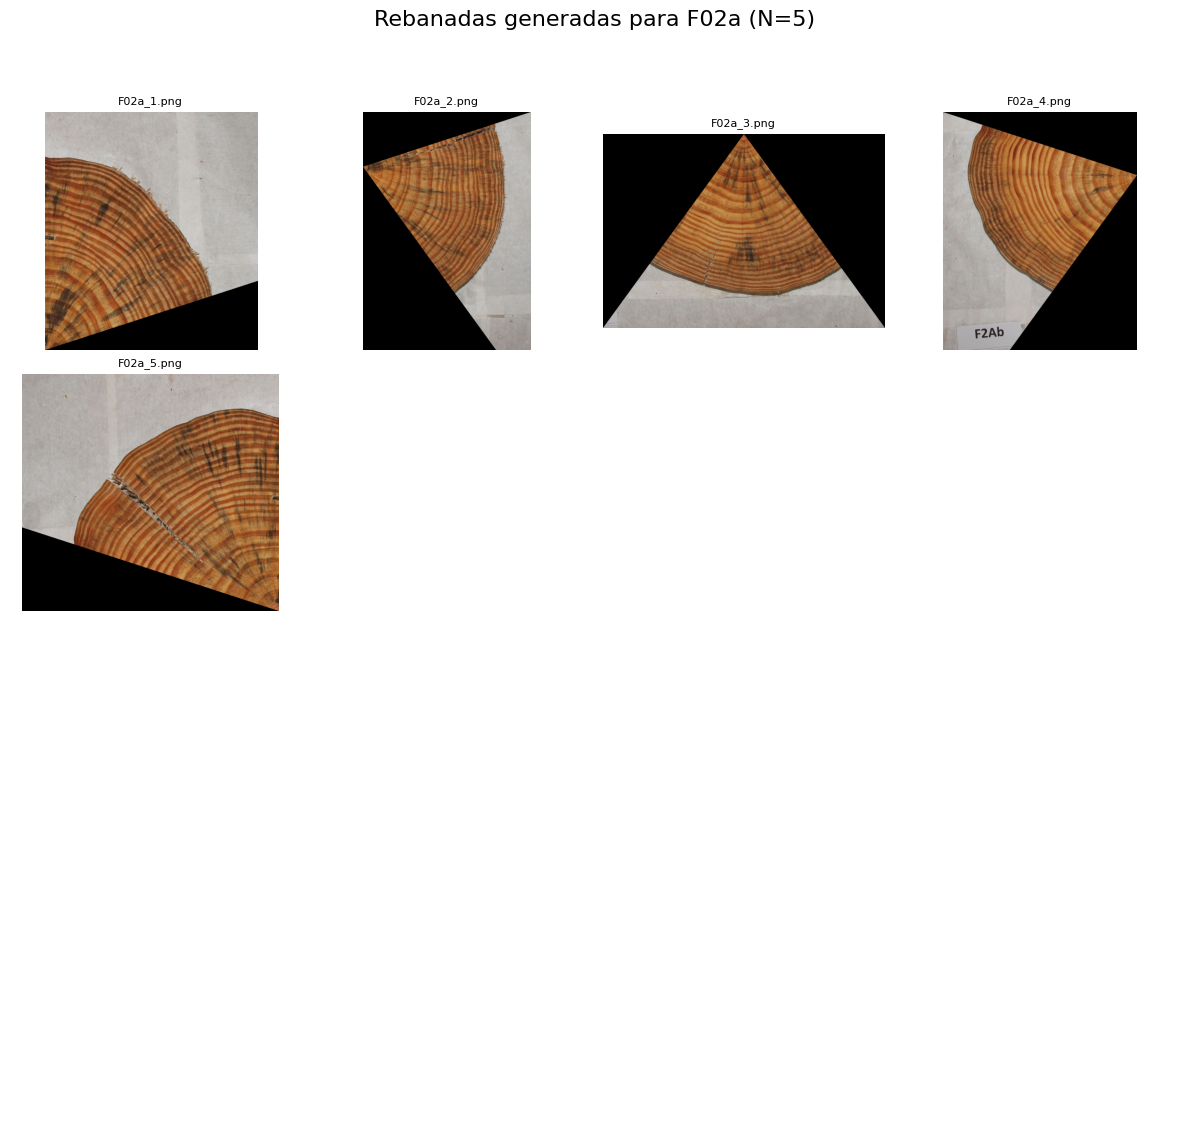

In [31]:
# --- 7. VERIFICACIÓN DE RESULTADOS ---

print(f"Mostrando resultados para la primera imagen procesada: {image_files[0]}")

image_name_no_ext = os.path.splitext(image_files[0])[0]
# Usar la ruta del HOST para encontrar los archivos generados
slice_dir = os.path.join(OUTPUT_HOST_PATH, str(N_SLICES), image_name_no_ext) # <--- FIX #6
slice_files = sorted(glob.glob(os.path.join(slice_dir, "*.png")))

if not slice_files:
    print(f"No se encontraron rebanadas generadas en {slice_dir}")
else:
    # Crear una grilla de 4x4 para mostrar las 16 rebanadas
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle(f'Rebanadas generadas para {image_name_no_ext} (N={N_SLICES})', fontsize=16)
    
    # Aplanar el array de ejes para una iteración fácil
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < len(slice_files):
            # Cargar la rebanada guardada
            slice_img = cv2.imread(slice_files[i])
            slice_img_rgb = cv2.cvtColor(slice_img, cv2.COLOR_BGR2RGB)
            
            ax.imshow(slice_img_rgb)
            ax.set_title(os.path.basename(slice_files[i]), fontsize=8)
            ax.axis('off')
        else:
            # Ocultar ejes si hay menos de 16 rebanadas
            ax.axis('off')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [32]:
# --- 8. DETENER LA SESIÓN DE SPARK ---
print("Deteniendo SparkSession...")
spark.stop()
print("Sesión detenida.")

Deteniendo SparkSession...
Sesión detenida.
Sesión detenida.
